In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Seaborn style
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("messy_ecommerce_15000_student_practice.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (15075, 16)


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,2025-08-27,4.1,7.0,No,4263.19
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,2025-06-18,4.2,4.0,No,2982.06
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,UPI,2025-01-13,3.6,2.0,No,1319.80
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (15075, 16)

Column Names:
['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Product_Category', 'Product', 'Quantity', 'Unit_Price', 'Discount', 'Payment_Method', 'Order_Date', 'Rating', 'Delivery_Days', 'Returned', 'Total_Amount']

Data Types:
Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
dtype: object

Missing Values:
Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method   

In [4]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
for column in numerical_columns:
    print("-", column)

Numerical Columns:
- Age
- Quantity
- Unit_Price
- Discount
- Rating
- Delivery_Days
- Total_Amount


In [5]:
numerical_summary = df[numerical_columns].describe()

numerical_summary

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,14804.000000,15075.000000,15075.000000,14954.000000,14694.000000,14895.000000,1.507500e+04
mean,32.315185,1.899768,7409.180453,12.016852,3.869171,4.489359,1.255336e+04
std,9.022506,1.076839,13950.011077,7.696562,0.741548,1.961563,2.955080e+04
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02
25%,26.000000,1.000000,1248.315000,5.000000,3.400000,3.000000,1.742195e+03
50%,32.000000,2.000000,2480.280000,10.000000,3.900000,4.000000,3.223750e+03
75%,38.000000,2.000000,3811.455000,15.000000,4.400000,6.000000,7.739260e+03
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06


In [6]:
mean_values = df[numerical_columns].mean()

print(mean_values)

Age                 32.315185
Quantity             1.899768
Unit_Price        7409.180453
Discount            12.016852
Rating               3.869171
Delivery_Days        4.489359
Total_Amount     12553.357032
dtype: float64


In [7]:
median_values = df[numerical_columns].median()

print(median_values)

Age                32.00
Quantity            2.00
Unit_Price       2480.28
Discount           10.00
Rating              3.90
Delivery_Days       4.00
Total_Amount     3223.75
dtype: float64


In [8]:
std_values = df[numerical_columns].std()

print(std_values)

Age                  9.022506
Quantity             1.076839
Unit_Price       13950.011077
Discount             7.696562
Rating               0.741548
Delivery_Days        1.961563
Total_Amount     29550.803498
dtype: float64


In [9]:
min_values = df[numerical_columns].min()
max_values = df[numerical_columns].max()

summary_min_max = pd.DataFrame({
    "Minimum": min_values,
    "Maximum": max_values
})

summary_min_max

,Minimum,Maximum
Age,5.00,99.00
Quantity,1.00,5.00
Unit_Price,425.61,309655.38
Discount,0.00,30.00
Rating,1.00,5.00
Delivery_Days,1.00,14.00
Total_Amount,298.27,1238621.52


In [10]:
percentiles = df[numerical_columns].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

percentiles

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
0.10,20.0,1.0,727.812,0.0,2.9,2.0,875.780
0.25,26.0,1.0,1248.315,5.0,3.4,3.0,1742.195
0.50,32.0,2.0,2480.280,10.0,3.9,4.0,3223.750
0.75,38.0,2.0,3811.455,15.0,4.4,6.0,7739.260
0.90,44.0,4.0,23330.426,25.0,4.9,7.0,34579.064


In [11]:
range_values = df[numerical_columns].max() - df[numerical_columns].min()

range_summary = pd.DataFrame({
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Range": range_values
}).sort_values("Range", ascending=False)

range_summary

,Minimum,Maximum,Range
Total_Amount,298.27,1238621.52,1238323.25
Unit_Price,425.61,309655.38,309229.77
Age,5.00,99.00,94.00
Discount,0.00,30.00,30.00
Delivery_Days,1.00,14.00,13.00
Quantity,1.00,5.00,4.00
Rating,1.00,5.00,4.00


In [12]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical Columns:")
for column in categorical_columns:
    print("-", column)

Categorical Columns:
- Order_ID
- Customer_ID
- Gender
- City
- Product_Category
- Product
- Payment_Method
- Order_Date
- Returned


In [13]:
categorical_summary = df[categorical_columns].describe()

categorical_summary

,Order_ID,Customer_ID,Gender,City,Product_Category,Product,Payment_Method,Order_Date,Returned
count,15075,15075,14896,14925,15075,15075,14849,15075,15075
unique,15000,6795,5,12,6,30,8,730,3
top,ORD111361,CUST4633,Female,Kolkata,Electronics,Smartwatch,Credit Card,2026-05-29,No
freq,2,8,7292,1274,3815,798,2510,41,13229


In [14]:
categorical_analysis = pd.DataFrame({
    "Unique Values": df[categorical_columns].nunique(),
    "Most Frequent Value": [
        df[column].mode()[0] if not df[column].mode().empty else np.nan
        for column in categorical_columns
    ],
    "Frequency": [
        df[column].value_counts().iloc[0] if not df[column].value_counts().empty else 0
        for column in categorical_columns
    ]
})

categorical_analysis

,Unique Values,Most Frequent Value,Frequency
Order_ID,15000,ORD100150,2
Customer_ID,6795,CUST1345,8
Gender,5,Female,7292
City,12,Kolkata,1274
Product_Category,6,Electronics,3815
Product,30,Smartwatch,798
Payment_Method,8,Credit Card,2510
Order_Date,730,2026-05-29,41
Returned,3,No,13229


In [15]:
columns_to_check = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Returned"
]

for column in columns_to_check:
    if column in df.columns:
        print(f"\nMost common {column}:")
        print(df[column].value_counts().head(1))


Most common Gender:
Gender
Female    7292
Name: count, dtype: int64

Most common City:
City
Kolkata    1274
Name: count, dtype: int64

Most common Product_Category:
Product_Category
Electronics    3815
Name: count, dtype: int64

Most common Payment_Method:
Payment_Method
Credit Card    2510
Name: count, dtype: int64

Most common Returned:
Returned
No    13229
Name: count, dtype: int64


In [16]:
for column in columns_to_check:
    if column in df.columns:
        print(f"\n{'='*50}")
        print(f"Unique values in {column}:")
        print(df[column].unique())
        print("Number of unique values:", df[column].nunique())


Unique values in Gender:
['Male' 'Female' 'Other' nan 'female' 'male']
Number of unique values: 5

Unique values in City:
['Hyderabad' 'Delhi' 'Pune' 'Chennai' 'Kolkata' 'Ahmedabad' 'Vijayawada'
 'Bengaluru' 'Guntur' 'Visakhapatnam' 'Warangal' 'Mumbai' nan]
Number of unique values: 12

Unique values in Product_Category:
['Fashion' 'Sports' 'Electronics' 'Home & Kitchen' 'Beauty' 'Books']
Number of unique values: 6

Unique values in Payment_Method:
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']
Number of unique values: 8

Unique values in Returned:
['No' 'Yes' 'yes']
Number of unique values: 3


In [17]:
for column in ["Gender", "Payment_Method", "Returned"]:
    if column in df.columns:
        print(f"\n{column}")
        print(df[column].value_counts(dropna=False))


Gender
Gender
Female    7292
Male      7023
Other      441
NaN        179
male        80
female      60
Name: count, dtype: int64

Payment_Method
Payment_Method
Credit Card    2510
Net Banking    2490
Wallet         2485
UPI            2450
Debit Card     2444
COD            2390
NaN             226
upi              40
credit card      40
Name: count, dtype: int64

Returned
Returned
No     13229
Yes     1816
yes       30
Name: count, dtype: int64


In [18]:
# Standardize Gender
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype("string").str.strip().str.title()

# Standardize Payment Method
if "Payment_Method" in df.columns:
    df["Payment_Method"] = df["Payment_Method"].astype("string").str.strip().str.title()

# Standardize Returned
if "Returned" in df.columns:
    df["Returned"] = df["Returned"].astype("string").str.strip().str.title()

print("Categorical values standardized.")

Categorical values standardized.


In [19]:
for column in ["Gender", "Payment_Method", "Returned"]:
    if column in df.columns:
        print(f"\n{column} after standardization:")
        print(df[column].value_counts(dropna=False))


Gender after standardization:
Gender
Female    7352
Male      7103
Other      441
<NA>       179
Name: count, dtype: Int64

Payment_Method after standardization:
Payment_Method
Credit Card    2550
Upi            2490
Net Banking    2490
Wallet         2485
Debit Card     2444
Cod            2390
<NA>            226
Name: count, dtype: Int64

Returned after standardization:
Returned
No     13229
Yes     1846
Name: count, dtype: Int64


In [20]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary

,Missing Count,Missing Percentage
Age,271,1.80
Gender,179,1.19
City,150,1.00
Discount,121,0.80
Payment_Method,226,1.50
Rating,381,2.53
Delivery_Days,180,1.19


In [21]:
missing_numerical = [
    column for column in numerical_columns
    if df[column].isnull().sum() > 0
]

missing_categorical = [
    column for column in categorical_columns
    if df[column].isnull().sum() > 0
]

print("Numerical columns with missing values:")
print(missing_numerical)

print("\nCategorical columns with missing values:")
print(missing_categorical)

Numerical columns with missing values:
['Age', 'Discount', 'Rating', 'Delivery_Days']

Categorical columns with missing values:
['Gender', 'City', 'Payment_Method']


In [22]:
for column in missing_numerical:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
    print(f"{column}: Missing values replaced with median = {median_value}")

Age: Missing values replaced with median = 32.0
Discount: Missing values replaced with median = 10.0
Rating: Missing values replaced with median = 3.9
Delivery_Days: Missing values replaced with median = 4.0


In [23]:
for column in missing_categorical:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)
    print(f"{column}: Missing values replaced with mode = {mode_value}")

Gender: Missing values replaced with mode = Female
City: Missing values replaced with mode = Kolkata
Payment_Method: Missing values replaced with mode = Credit Card


In [24]:
missing_after = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_after

,Missing Count,Missing Percentage
Order_ID,0,0.0
Customer_ID,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0
Product_Category,0,0.0
Product,0,0.0
Quantity,0,0.0
Unit_Price,0,0.0
Discount,0,0.0


In [25]:
print("Dataset dimensions after missing-value treatment:", df.shape)

if df.isnull().sum().sum() == 0:
    print("The dataset is completely free of missing values.")
else:
    print("Missing values are still present.")

Dataset dimensions after missing-value treatment: (15075, 16)
The dataset is completely free of missing values.


In [26]:
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(20)

Total duplicate rows: 75


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
137,ORD100388,CUST3880,43.0,Female,Vijayawada,Books,Novel,1,434.72,15.0,Net Banking,2026-06-20,3.4,5.0,Yes,369.51
138,ORD100170,CUST2577,18.0,Female,Bengaluru,Books,Novel,2,513.28,5.0,Credit Card,2025-01-27,3.4,6.0,Yes,975.24
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,2026-06-25,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,2026-06-25,5.0,6.0,No,5349.58
237,ORD110505,CUST7475,36.0,Male,Ahmedabad,Beauty,Face Wash,5,572.40,20.0,Debit Card,2025-05-09,3.9,7.0,No,2289.60


In [27]:
if "Order_ID" in df.columns:
    duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

    print("Number of records with duplicate Order_ID:")
    print(len(duplicate_order_ids))

    duplicate_order_ids.head(20)

Number of records with duplicate Order_ID:
150


In [28]:
exact_duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_count)

if "Order_ID" in df.columns:
    order_id_duplicate_count = df["Order_ID"].duplicated().sum()
    print("Duplicate Order_ID occurrences:", order_id_duplicate_count)

Exact duplicate rows: 75
Duplicate Order_ID occurrences: 75


In [29]:
records_before_duplicates = len(df)

df = df.drop_duplicates()

records_after_duplicates = len(df)

print("Records before removing duplicates:", records_before_duplicates)
print("Duplicate records removed:", records_before_duplicates - records_after_duplicates)
print("Records after removing duplicates:", records_after_duplicates)

Records before removing duplicates: 15075
Duplicate records removed: 75
Records after removing duplicates: 15000


In [30]:
print("Remaining exact duplicate rows:", df.duplicated().sum())
print("Current dataset shape:", df.shape)

Remaining exact duplicate rows: 0
Current dataset shape: (15000, 16)


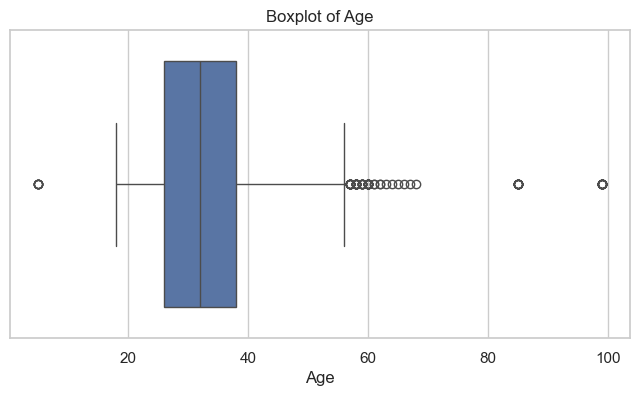

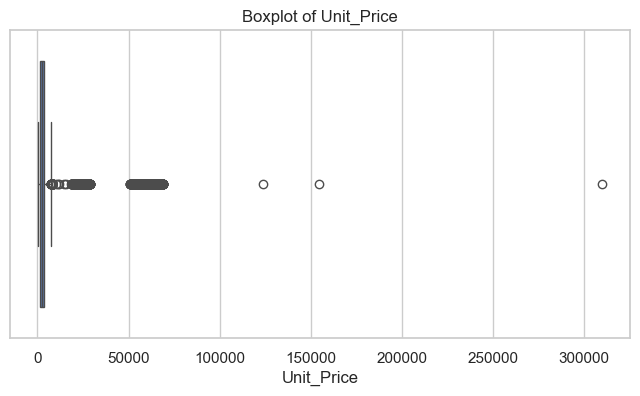

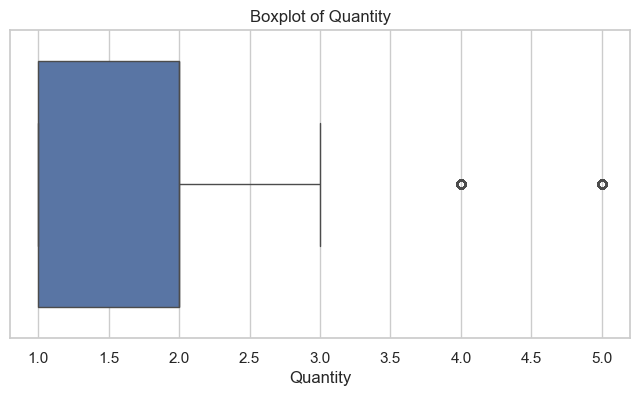

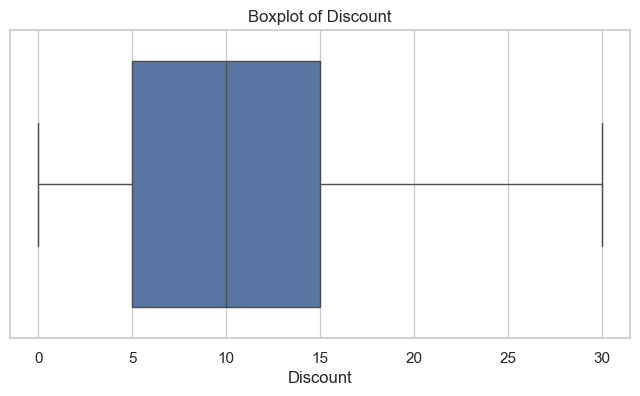

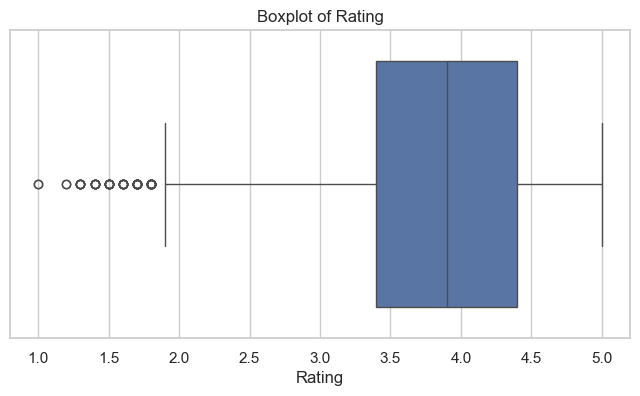

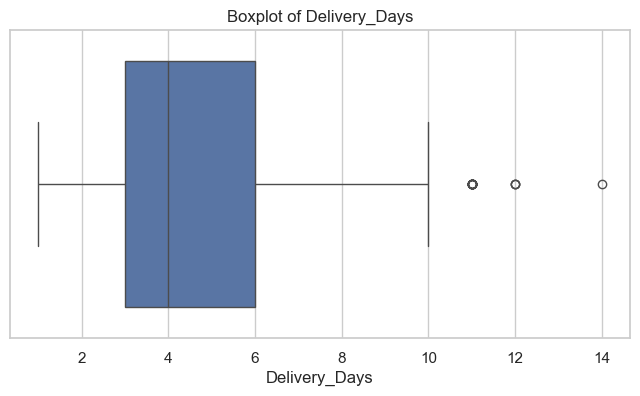

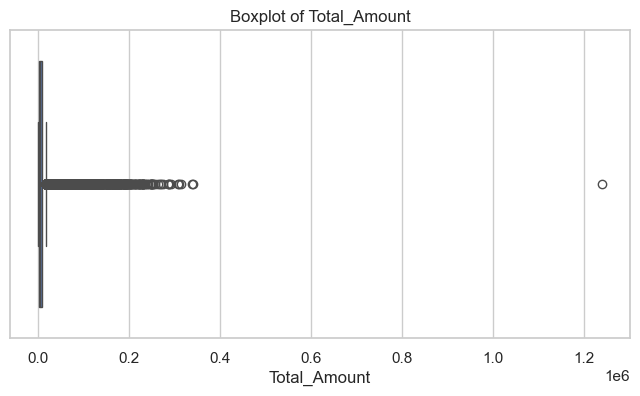

In [31]:
outlier_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

for column in outlier_columns:
    if column in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")
        plt.xlabel(column)
        plt.show()

In [32]:
outlier_summary = {}

for column in outlier_columns:
    if column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

        outlier_summary[column] = count

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

outlier_summary

Total_Amount     2472
Unit_Price       2401
Quantity         1513
Age                90
Rating             73
Delivery_Days      24
Discount            0
dtype: int64

In [33]:
iqr_columns = ["Age", "Unit_Price", "Total_Amount"]

iqr_results = []

for column in iqr_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    iqr_results.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

iqr_summary = pd.DataFrame(iqr_results)

iqr_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,26.00,38.0000,12.0000,8.00000,56.00000,90
1,Unit_Price,1249.04,3819.2975,2570.2575,-2606.34625,7674.68375,2401
2,Total_Amount,1741.91,7741.0100,5999.1000,-7256.74000,16739.66000,2472


In [34]:
for column in iqr_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column} - Number of outliers: {len(outliers)}")
    display(outliers.head(10))


Age - Number of outliers: 90


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
98,ORD107435,CUST4989,99.0,Female,Visakhapatnam,Electronics,Headphones,3,2639.46,0.0,Net Banking,2025-03-04,3.8,2.0,Yes,7918.39
703,ORD100765,CUST3086,57.0,Female,Chennai,Books,Novel,2,456.55,25.0,Upi,2025-02-04,4.0,2.0,No,684.82
748,ORD110979,CUST2685,60.0,Female,Warangal,Home & Kitchen,Lamp,2,1168.98,10.0,Credit Card,2025-06-23,4.8,6.0,No,2104.17
885,ORD100837,CUST7489,60.0,Female,Vijayawada,Beauty,Face Wash,3,548.89,5.0,Cod,2026-04-20,3.5,8.0,No,1564.35
1001,ORD101745,CUST8544,99.0,Male,Hyderabad,Beauty,Makeup Kit,2,2460.28,30.0,Cod,2025-07-31,2.1,4.0,No,3444.39
1180,ORD100182,CUST2531,5.0,Female,Hyderabad,Sports,Football,3,1172.53,20.0,Wallet,2026-02-12,3.3,3.0,No,2814.06
1587,ORD110402,CUST4342,99.0,Male,Vijayawada,Electronics,Laptop,2,63468.20,10.0,Upi,2026-03-25,4.5,6.0,No,114242.76
1589,ORD104163,CUST2343,58.0,Female,Mumbai,Sports,Football,3,1135.02,5.0,Debit Card,2026-07-17,5.0,4.0,No,3234.80
1754,ORD109073,CUST6503,61.0,Female,Kolkata,Beauty,Perfume,2,1860.57,15.0,Upi,2025-02-05,4.6,4.0,No,3162.97



Unit_Price - Number of outliers: 2401


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,Upi,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,2026-06-07,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,2025-12-12,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,2026-09-13,4.9,6.0,No,65832.03
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,2025-10-21,3.9,1.0,No,159469.68
44,ORD104430,CUST8230,18.0,Female,Pune,Electronics,Laptop,1,68538.16,10.0,Upi,2026-10-27,3.6,4.0,No,61684.35
58,ORD108383,CUST7971,25.0,Male,Warangal,Electronics,Tablet,1,19498.77,10.0,Credit Card,2026-07-13,3.9,8.0,No,17548.90
59,ORD111348,CUST2633,50.0,Male,Warangal,Electronics,Smartphone,2,26179.31,30.0,Credit Card,2025-01-05,2.9,2.0,No,36651.03



Total_Amount - Number of outliers: 2472


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,2026-06-07,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,2025-12-12,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,2026-09-13,4.9,6.0,No,65832.03
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,2025-10-21,3.9,1.0,No,159469.68
44,ORD104430,CUST8230,18.0,Female,Pune,Electronics,Laptop,1,68538.16,10.0,Upi,2026-10-27,3.6,4.0,No,61684.35
58,ORD108383,CUST7971,25.0,Male,Warangal,Electronics,Tablet,1,19498.77,10.0,Credit Card,2026-07-13,3.9,8.0,No,17548.90
59,ORD111348,CUST2633,50.0,Male,Warangal,Electronics,Smartphone,2,26179.31,30.0,Credit Card,2025-01-05,2.9,2.0,No,36651.03
68,ORD104609,CUST3954,18.0,Other,Vijayawada,Electronics,Smartphone,3,27616.08,15.0,Wallet,2025-05-30,4.5,2.0,No,70421.00
73,ORD111323,CUST1838,43.0,Male,Guntur,Home & Kitchen,Air Fryer,3,7266.47,20.0,Upi,2025-07-01,4.4,2.0,No,17439.54


In [35]:
df["Expected_Total"] = (
    df["Unit_Price"] *
    df["Quantity"] *
    (1 - df["Discount"] / 100)
)

df["Amount_Difference"] = (
    df["Total_Amount"] - df["Expected_Total"]
)

df[[
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total",
    "Amount_Difference"
]].head(10)

,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Amount_Difference
0,2507.76,2,15.0,4263.19,4263.1920,-0.0020
1,1988.04,2,25.0,2982.06,2982.0600,0.0000
2,776.35,2,15.0,1319.80,1319.7950,0.0050
3,7739.89,1,10.0,6965.90,6965.9010,-0.0010
4,61138.76,1,5.0,58081.82,58081.8220,-0.0020
5,1890.11,1,10.0,1701.10,1701.0990,0.0010
6,5999.83,1,15.0,5099.86,5099.8555,0.0045
7,6760.65,1,20.0,5408.52,5408.5200,0.0000
8,2830.42,2,5.0,5377.80,5377.7980,0.0020
9,21716.46,2,10.0,39089.63,39089.6280,0.0020


In [36]:
difference_threshold = df["Amount_Difference"].abs().quantile(0.95)

large_differences = df[
    df["Amount_Difference"].abs() > difference_threshold
].copy()

print("Difference threshold:", difference_threshold)
print("Records with large differences:", len(large_differences))

large_differences[[
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total",
    "Amount_Difference"
]].head(20)

Difference threshold: 0.012500000000727596
Records with large differences: 743


,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Amount_Difference
14,1394.37,3,10.0,3555.64,3764.799,-209.159
70,2454.31,4,15.0,8344.64,8344.654,-0.014
75,740.74,4,15.0,2518.53,2518.516,0.014
99,2463.28,3,10.0,6650.87,6650.856,0.014
100,24538.28,3,10.0,66253.37,66253.356,0.014
110,2302.94,3,15.0,5872.51,5872.497,0.013
119,3174.41,2,10.0,4761.62,5713.938,-952.318
176,19438.73,4,0.0,77754.90,77754.920,-0.020
183,22540.06,5,25.0,84525.24,84525.225,0.015
186,2765.13,4,5.0,10507.51,10507.494,0.016


In [37]:
print("========== DATA QUALITY CHECK ==========")

print("\n1. Dataset Dimensions:")
print(df.shape)

print("\n2. Data Types:")
print(df.dtypes)

print("\n3. Missing Values:")
print(df.isnull().sum().sum())

print("\n4. Duplicate Records:")
print(df.duplicated().sum())

print("\n5. Unique Values:")
for column in ["Gender", "City", "Product_Category", "Payment_Method", "Returned"]:
    if column in df.columns:
        print(f"{column}: {df[column].nunique()}")

print("\n6. Numerical Statistical Summary:")
display(df[numerical_columns].describe())

print("\n7. Data Consistency:")
print("Expected_Total and Amount_Difference columns calculated successfully.")

========== DATA QUALITY CHECK ==========

1. Dataset Dimensions:
(15000, 18)

2. Data Types:
Order_ID                     object
Customer_ID                  object
Age                         float64
Gender               string[python]
City                         object
Product_Category             object
Product                      object
Quantity                      int64
Unit_Price                  float64
Discount                    float64
Payment_Method       string[python]
Order_Date                   object
Rating                      float64
Delivery_Days               float64
Returned             string[python]
Total_Amount                float64
Expected_Total              float64
Amount_Difference           float64
dtype: object

3. Missing Values:
0

4. Duplicate Records:
0

5. Unique Values:
Gender: 3
City: 12
Product_Category: 6
Payment_Method: 6
Returned: 2

6. Numerical Statistical Summary:


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04
mean,32.303267,1.899000,7417.831243,12.008000,3.869920,4.483800,1.256593e+04
std,8.939461,1.076635,13958.314015,7.667802,0.732387,1.950656,2.956941e+04
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02
25%,26.000000,1.000000,1249.040000,5.000000,3.400000,3.000000,1.741910e+03
50%,32.000000,2.000000,2480.995000,10.000000,3.900000,4.000000,3.226920e+03
75%,38.000000,2.000000,3819.297500,15.000000,4.400000,6.000000,7.741010e+03
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06



7. Data Consistency:
Expected_Total and Amount_Difference columns calculated successfully.


In [38]:
date_columns = df.select_dtypes(include=["datetime64"]).columns.tolist()

print("Existing datetime columns:", date_columns)

# Check object columns that may contain dates
for column in df.select_dtypes(include="object").columns:
    if "date" in column.lower():
        converted_dates = pd.to_datetime(df[column], errors="coerce")
        print(f"\n{column}")
        print("Valid date values:", converted_dates.notna().sum())
        print("Invalid/missing date values:", converted_dates.isna().sum())

Existing datetime columns: []

Order_Date
Valid date values: 15000
Invalid/missing date values: 0


In [39]:
cleaned_file = "cleaned_ecommerce_dataset.csv"

df.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved successfully as: {cleaned_file}")

Cleaned dataset saved successfully as: cleaned_ecommerce_dataset.csv


In [40]:
cleaned_df = pd.read_csv("cleaned_ecommerce_dataset.csv")

print("Cleaned dataset shape:", cleaned_df.shape)
print("File loaded successfully.")
cleaned_df.head()

Cleaned dataset shape: (15000, 18)
File loaded successfully.


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount,Expected_Total,Amount_Difference
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,2025-08-27,4.1,7.0,No,4263.19,4263.192,-0.002
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,2025-06-18,4.2,4.0,No,2982.06,2982.060,0.000
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,Upi,2025-01-13,3.6,2.0,No,1319.80,1319.795,0.005
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,Upi,2026-06-01,3.2,6.0,Yes,6965.90,6965.901,-0.001
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82,58081.822,-0.002


In [41]:
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

print("Cleaned dataset loaded.")
print("Shape:", df.shape)

Cleaned dataset loaded.
Shape: (15000, 18)


/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


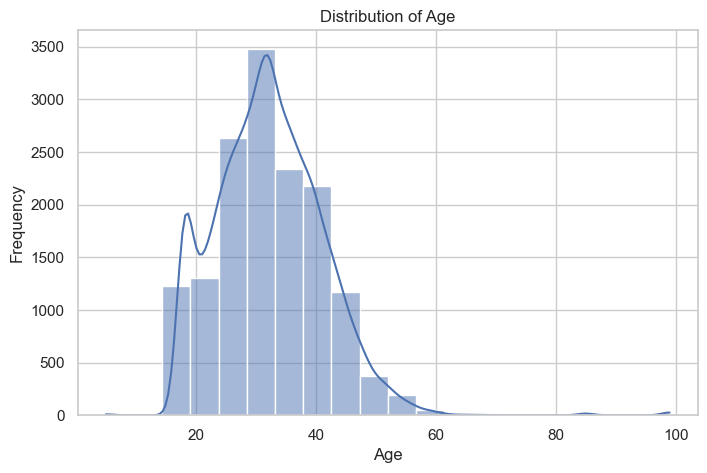

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


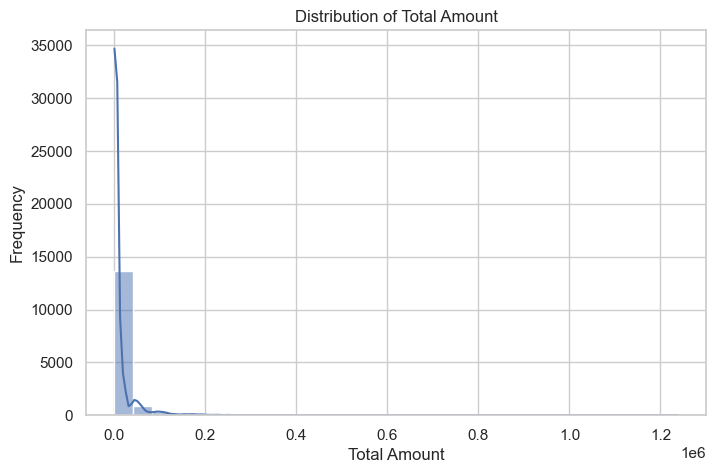

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Total_Amount", bins=30, kde=True)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


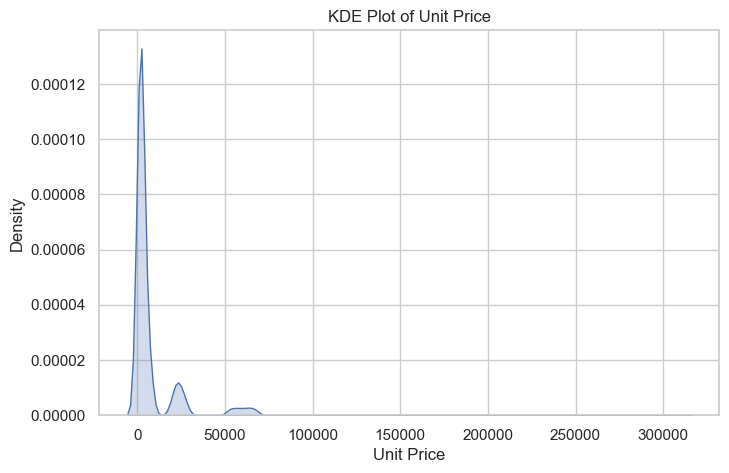

In [44]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Unit_Price", fill=True)
plt.title("KDE Plot of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.show()

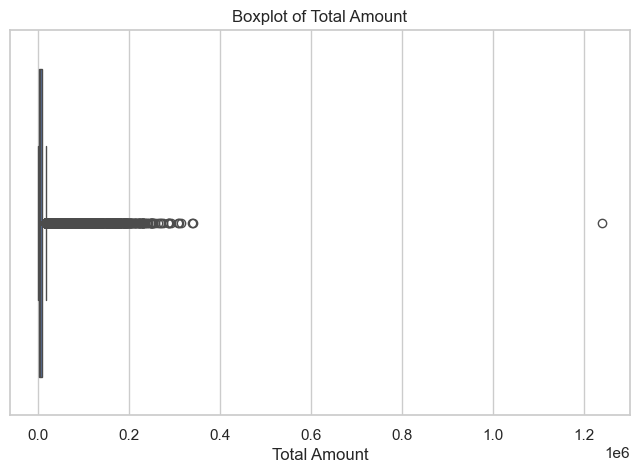

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Total_Amount")
plt.title("Boxplot of Total Amount")
plt.xlabel("Total Amount")
plt.show()

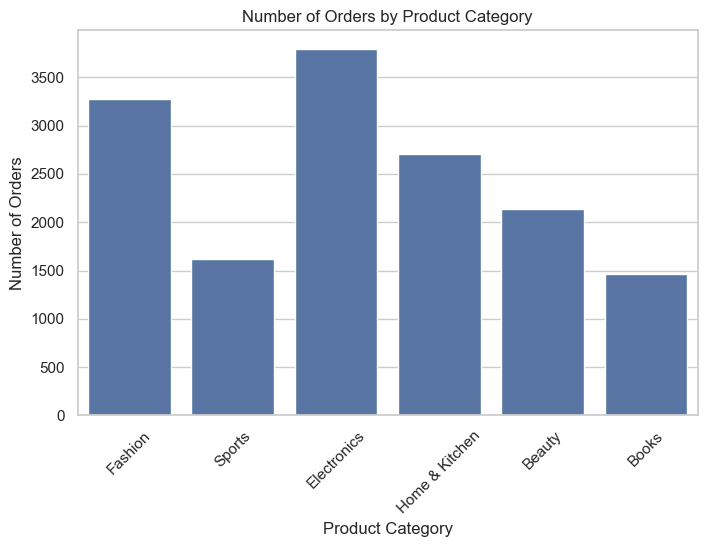

In [46]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Product_Category")
plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

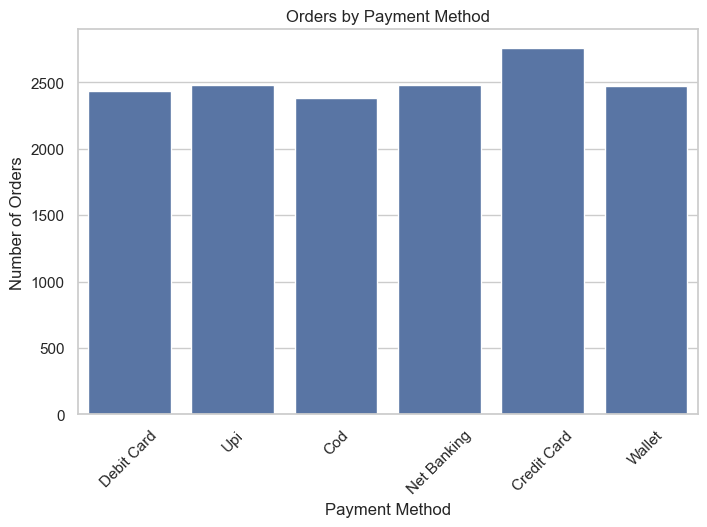

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Payment_Method")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

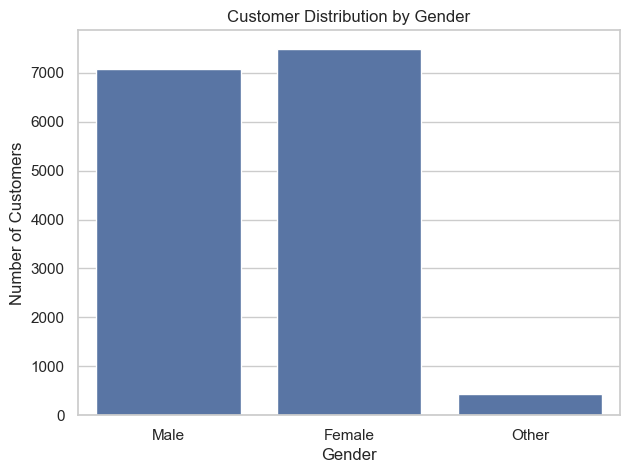

In [48]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

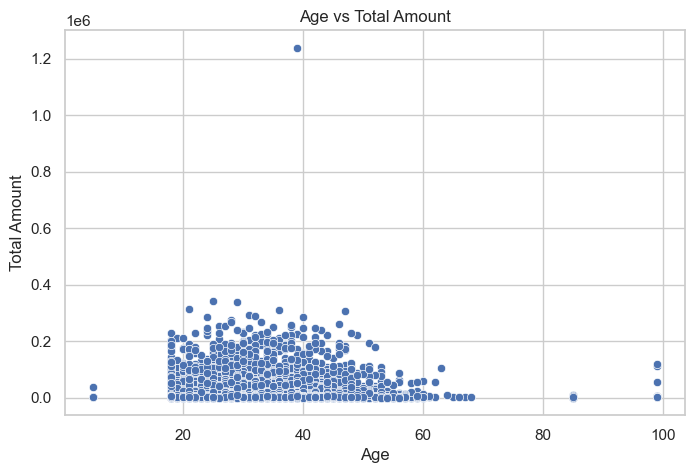

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Total_Amount")
plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

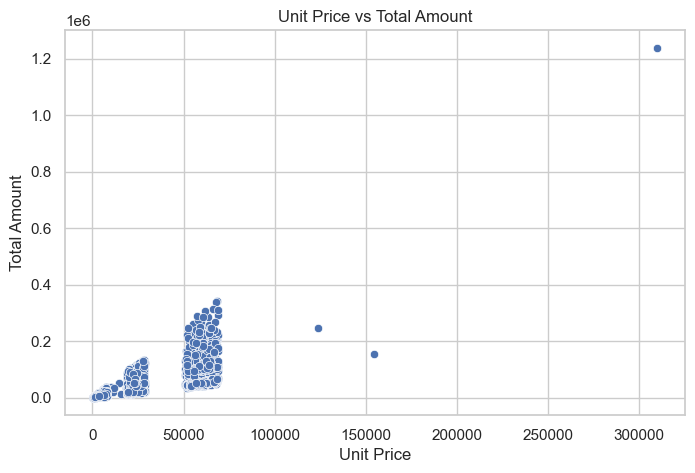

In [50]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Unit_Price", y="Total_Amount")
plt.title("Unit Price vs Total Amount")
plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.show()

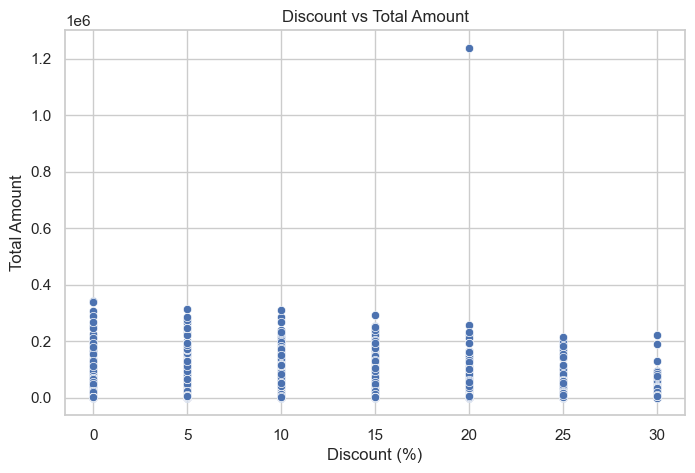

In [51]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Total_Amount")
plt.title("Discount vs Total Amount")
plt.xlabel("Discount (%)")
plt.ylabel("Total Amount")
plt.show()

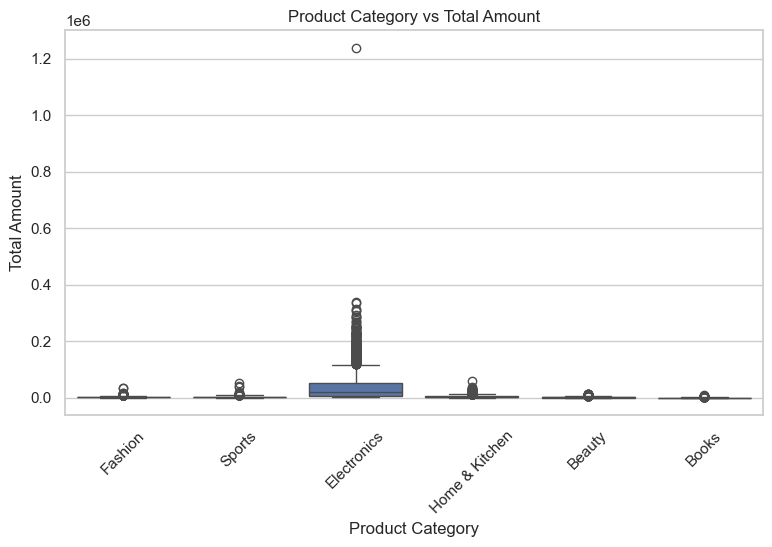

In [52]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Product_Category", y="Total_Amount")
plt.title("Product Category vs Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

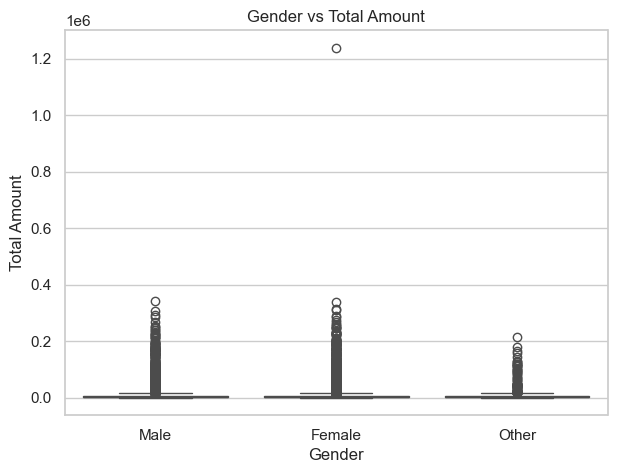

In [53]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Gender", y="Total_Amount")
plt.title("Gender vs Total Amount")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

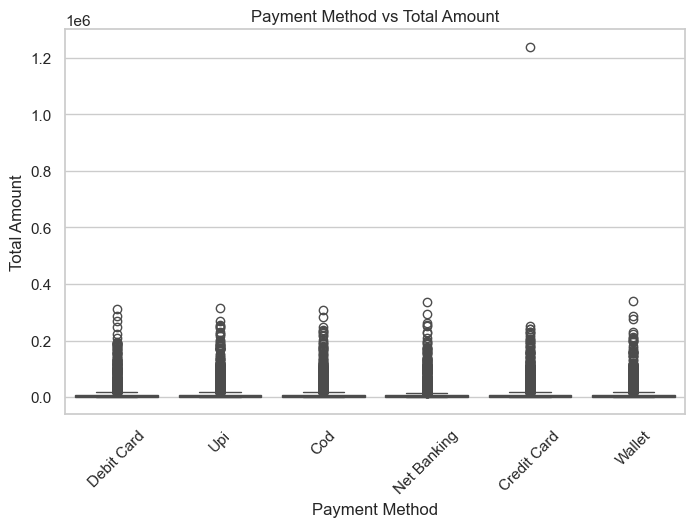

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Payment_Method", y="Total_Amount")
plt.title("Payment Method vs Total Amount")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

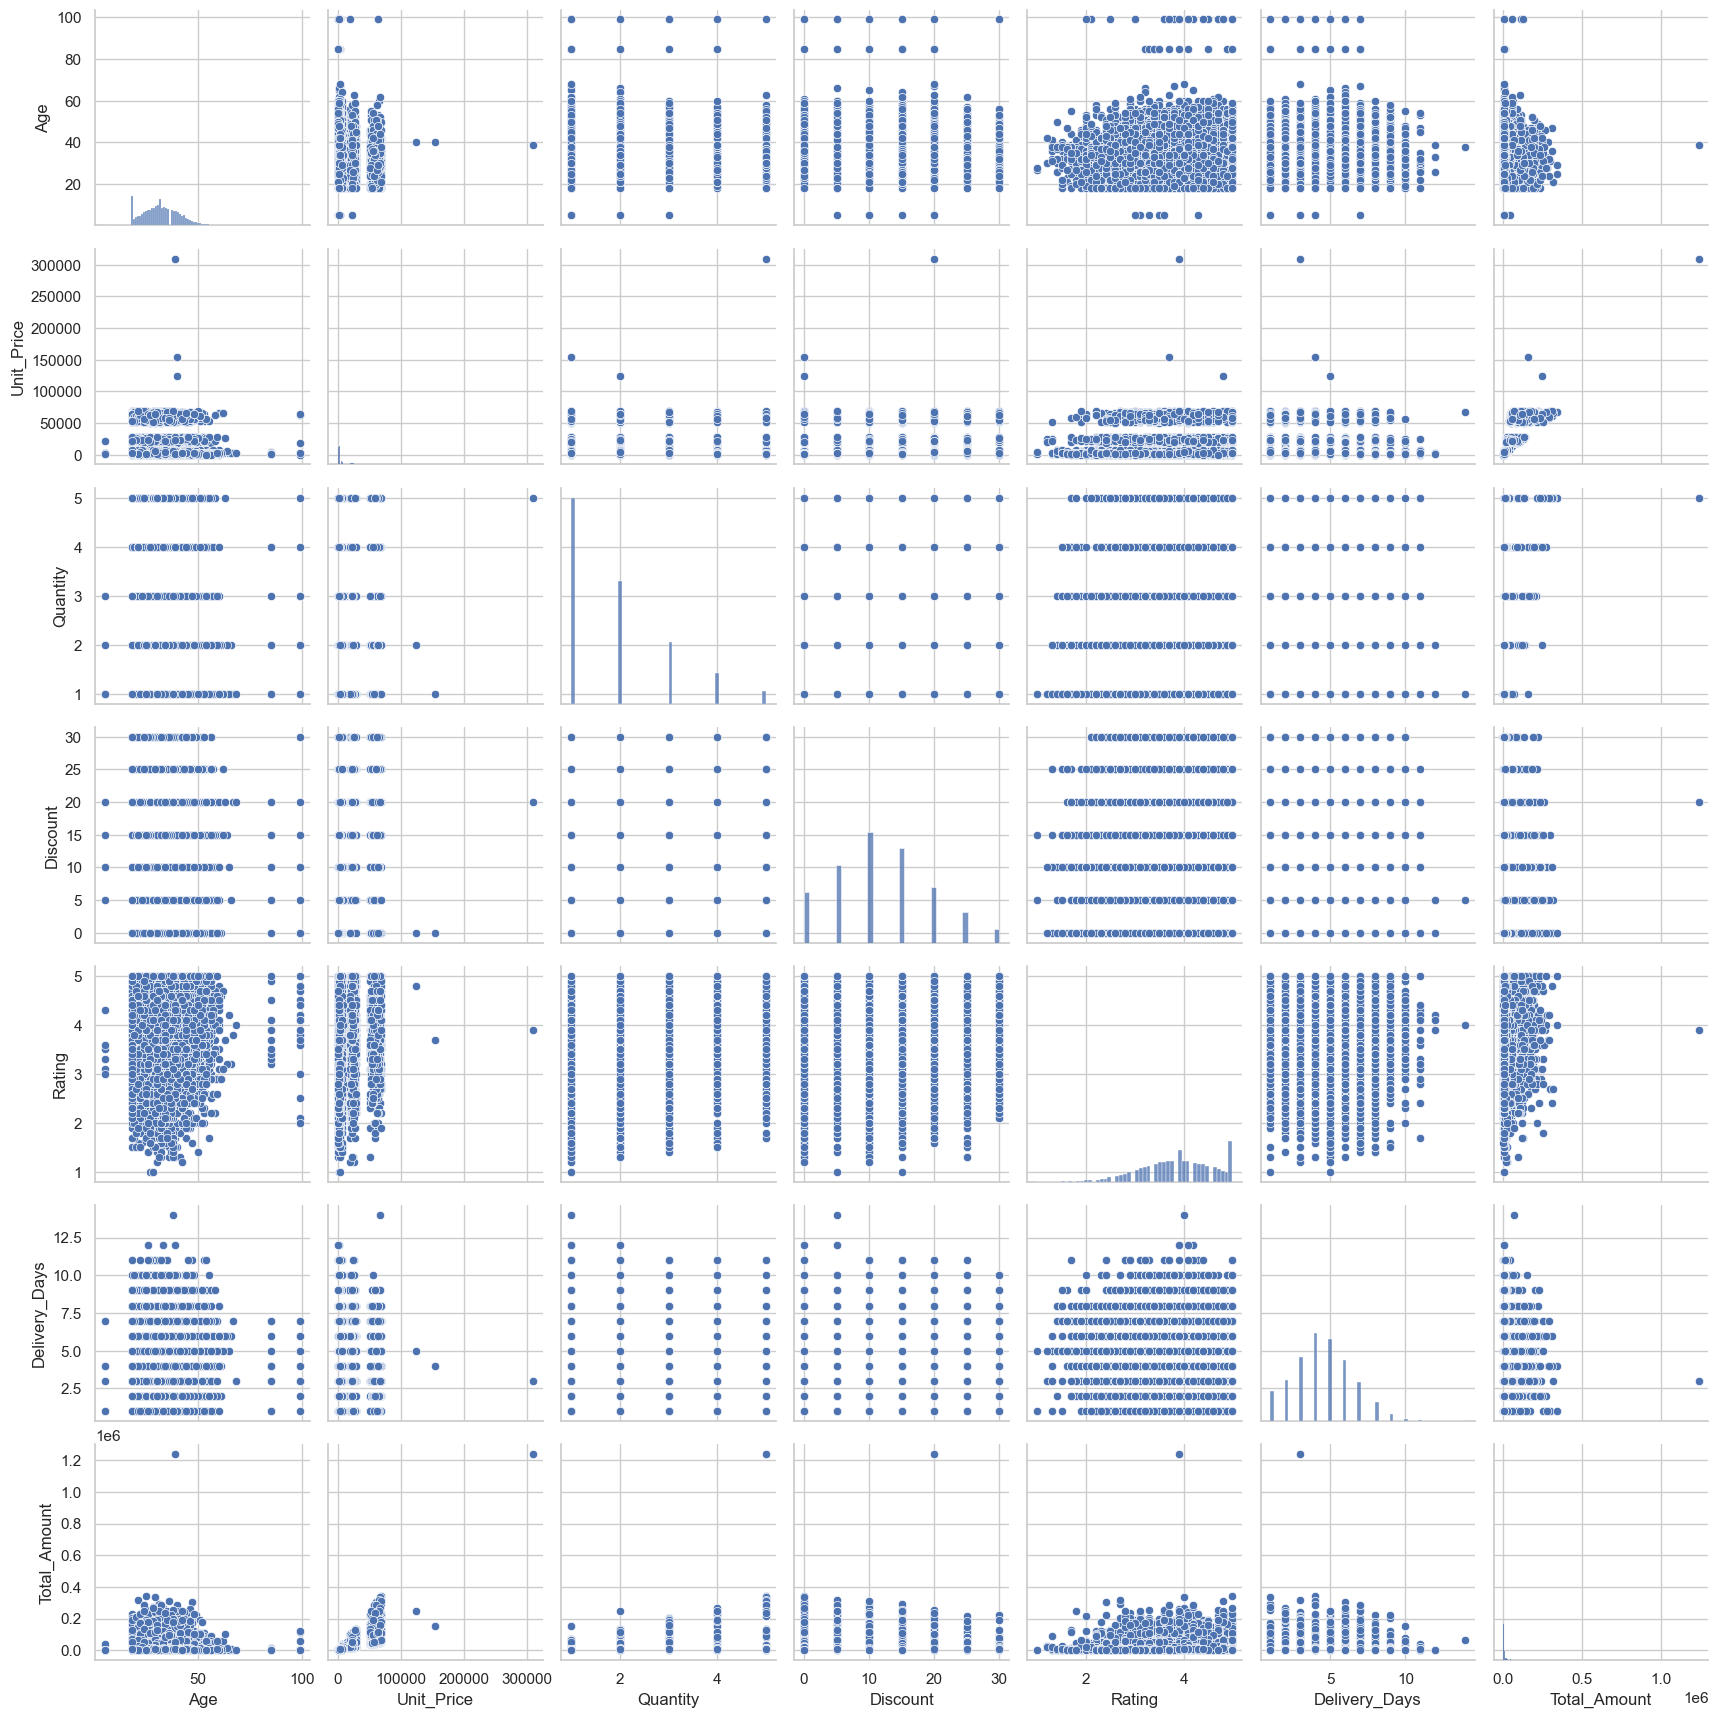

In [55]:
pairplot_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

sns.pairplot(df[pairplot_columns].dropna())
plt.show()

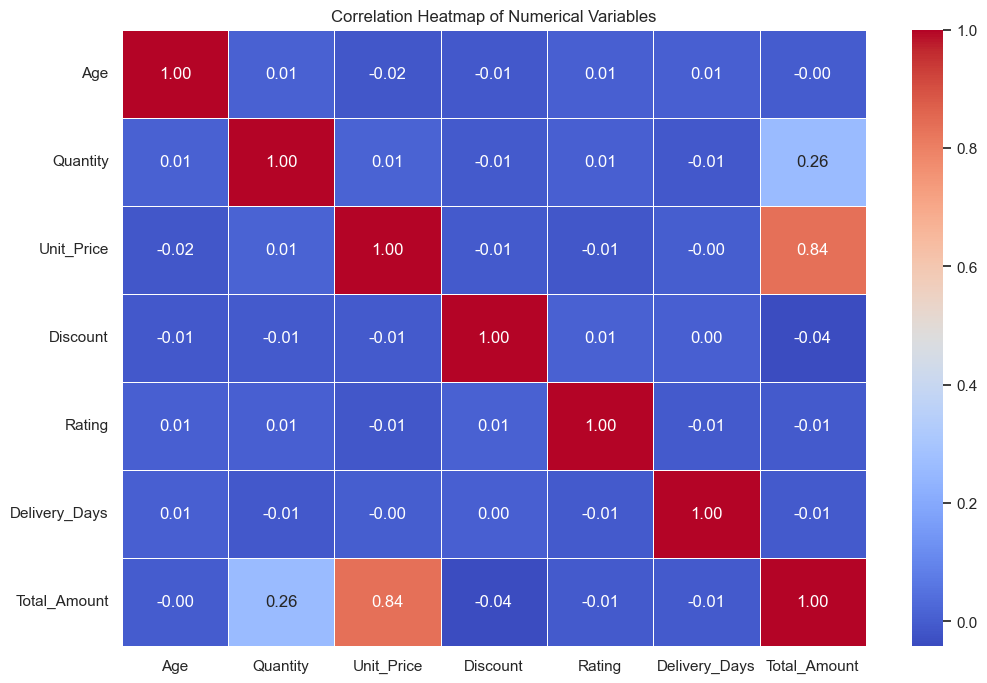

In [56]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [57]:
plt.figure(figsize=(9, 5))blob:vscode-webview://1f0sgu1ftpvm1vshd4k4rm5htr894n0qijc1k4363aj7v590h0ft/e26a21a7-4cd3-4a5c-b36c-6acbdb0546c4
sns.countplot(
    data=df,
    x="Product_Category",
    hue="Gender"
)

plt.title("Product Category Distribution by Gender")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

SyntaxError: invalid decimal literal (3493270925.py, line 1)

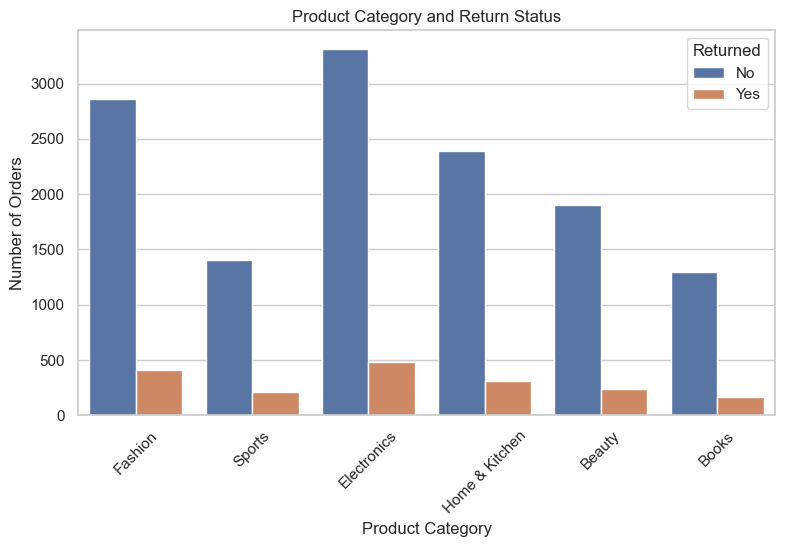

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Product_Category",
    hue="Returned"
)

plt.title("Product Category and Return Status")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

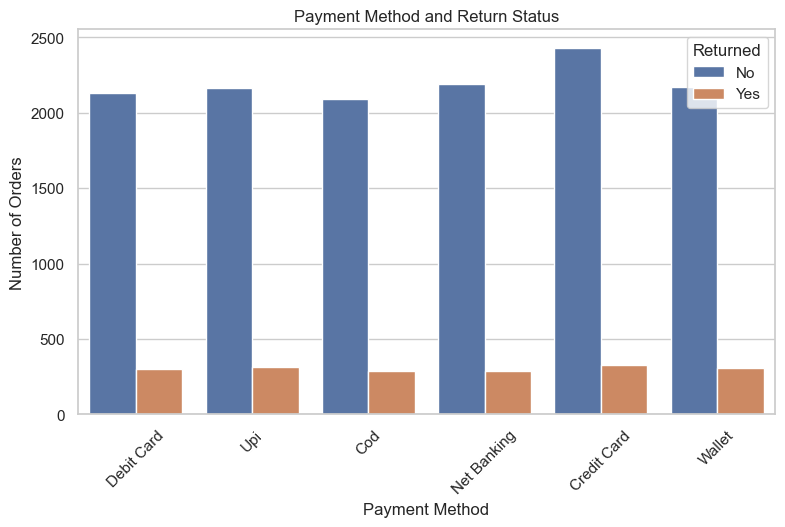

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Returned"
)

plt.title("Payment Method and Return Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
Age,1.000000,0.011426,-0.016544,-0.009784,0.005734,0.006673,-0.004330
Quantity,0.011426,1.000000,0.012130,-0.005515,0.007088,-0.009716,0.255942
Unit_Price,-0.016544,0.012130,1.000000,-0.005659,-0.014778,-0.000417,0.835066
Discount,-0.009784,-0.005515,-0.005659,1.000000,0.007764,0.004916,-0.041234
Rating,0.005734,0.007088,-0.014778,0.007764,1.000000,-0.007873,-0.008006
Delivery_Days,0.006673,-0.009716,-0.000417,0.004916,-0.007873,1.000000,-0.007124
Total_Amount,-0.004330,0.255942,0.835066,-0.041234,-0.008006,-0.007124,1.000000


In [ ]:
corr = correlation_matrix.copy()

# Remove self-correlations
np.fill_diagonal(corr.values, np.nan)

strongest_positive = corr.stack().idxmax()
strongest_positive_value = corr.stack().max()

strongest_negative = corr.stack().idxmin()
strongest_negative_value = corr.stack().min()

print("Strongest positive correlation:")
print(strongest_positive, "=", round(strongest_positive_value, 3))

print("\nStrongest negative correlation:")
print(strongest_negative, "=", round(strongest_negative_value, 3))

Strongest positive correlation:
('Unit_Price', 'Total_Amount') = 0.835

Strongest negative correlation:
('Discount', 'Total_Amount') = -0.041


In [ ]:
total_amount_correlation = (
    correlation_matrix["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Total_Amount:")
print(total_amount_correlation)

Correlation with Total_Amount:
Unit_Price       0.835066
Quantity         0.255942
Discount        -0.041234
Rating          -0.008006
Delivery_Days   -0.007124
Age             -0.004330
Name: Total_Amount, dtype: float64


In [ ]:
print("========== BUSINESS INSIGHTS ==========")

# 1. Most ordered product category
most_ordered_category = df["Product_Category"].value_counts().idxmax()
print("1. Most ordered product category:", most_ordered_category)

# 2. Highest average order value by category
highest_avg_category = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .idxmax()
)
print("2. Category with highest average order value:", highest_avg_category)

# 3. Most popular payment method
popular_payment = df["Payment_Method"].value_counts().idxmax()
print("3. Most popular payment method:", popular_payment)

# 4. City with highest sales
highest_sales_city = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .idxmax()
)
print("4. City with highest sales:", highest_sales_city)

# 5. Gender with highest average spending
highest_gender_spending = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .idxmax()
)
print("5. Gender with highest average spending:", highest_gender_spending)

# 6. Discount and Total Amount correlation
discount_correlation = df["Discount"].corr(df["Total_Amount"])
print("6. Discount vs Total Amount correlation:", round(discount_correlation, 3))

# 7. Product category with highest average rating
highest_rated_category = (
    df.groupby("Product_Category")["Rating"]
    .mean()
    .idxmax()
)
print("7. Highest average-rated category:", highest_rated_category)

# 8. Return percentage
return_percentage = (
    df["Returned"].value_counts(normalize=True) * 100
)
print("\n8. Return status percentage:")
print(return_percentage)

# 9. Delivery days vs rating
delivery_rating_correlation = df["Delivery_Days"].corr(df["Rating"])
print("9. Delivery Days vs Rating correlation:", round(delivery_rating_correlation, 3))

# 10. Strongest numerical relationship with Total Amount
strongest_total_amount_feature = total_amount_correlation.index[0]
print(
    "10. Feature with strongest correlation with Total Amount:",
    strongest_total_amount_feature
)

========== BUSINESS INSIGHTS ==========
1. Most ordered product category: Electronics
2. Category with highest average order value: Electronics
3. Most popular payment method: Credit Card
4. City with highest sales: Kolkata
5. Gender with highest average spending: Other
6. Discount vs Total Amount correlation: -0.041
7. Highest average-rated category: Beauty

8. Return status percentage:
Returned
No     87.793333
Yes    12.206667
Name: proportion, dtype: float64
9. Delivery Days vs Rating correlation: -0.008
10. Feature with strongest correlation with Total Amount: Unit_Price


Business Insights — Interpretation

1. The product category with the highest number of orders represents the strongest demand among customers.
2. The category with the highest average Total Amount generates the highest average order value.
3. The most frequently used payment method represents the preferred payment option among customers.
4. The city with the highest total sales contributes the greatest sales value.
5. Differences in average spending between gender categories can indicate different purchasing patterns.
6. The correlation between Discount and Total Amount indicates whether the two variables have a noticeable linear relationship.
7. Average ratings can help identify product categories with better customer satisfaction.
8. The return percentage indicates the proportion of orders that were returned.
9. The correlation between Delivery Days and Rating helps determine whether delivery time is associated with customer ratings.
10. Features with stronger correlations with Total Amount may be useful for further predictive analysis.

Final Conclusion

The e-commerce dataset was analyzed using Pandas, Matplotlib, and Seaborn.

The analysis included:

1.Numerical and categorical data analysis
2.Statistical summaries
3.Identification of unique and inconsistent categorical values
4.Missing-value treatment
5.Duplicate detection and removal
6.Outlier detection using boxplots and the IQR method
7.Data consistency validation
8.Final data-quality checks
9.Univariate, bivariate, and multivariate visualizations
10.Correlation analysis
11.Business insight generation

The cleaned dataset was saved separately as `cleaned_ecommerce_dataset.csv`, keeping the original dataset unchanged.

Overall, the cleaned dataset is suitable for exploratory data analysis, provided that the identified extreme values and data-consistency issues are considered when interpreting the results.